# Customer Churn Classification

# 1. Business Understanding
In the dynamic world of telecommunications, customer churn remains a pressing challenge for companies striving to achieve sustained success. Customers have alot of options and evolving preferences. Accurately predicting churn has become important to retain and satisfy them. Customer churn is essentially the loss of customers.

In this project, we use Supervised Machine Learning (classification) to explore the significance of churn analytics as a strategic tool for telecommunication companies to proactively identify potential risk factors for churn, optimize retention efforts, and cultivate lasting customer relationships. By leveraging data-driven insights and advanced analytics, companies can gain a competitive edge and ensure sustainable growth in an ever-changing industry.

The churn analytics predictive model is a data-driven solution designed to address the persistent challenge of customer churn in subscription-based industries. This model aims to identify customers at risk of churn, enabling businesses to take proactive measures and implement targeted retention strategies. 

The primary objective is to reduce customer churn rates and retain valuable customers by providing insights into customer behavior, preferences, and patterns. Utilizing machine learning models such as logistic regression and decision trees, the model evaluates the data to build accurate predictions. 

Its performance is assessed through metrics like accuracy, precision, recall and F1-score. Armed with the model's insights, businesses can create personalized offers, marketing campaigns, and proactive customer support initiatives, thus improving customer satisfaction and fostering loyalty. 

## Hypothesis

**Null Hypothesis (H0)**:
"There is no significant relationship between customer tenure and churn rate in the telecom company."

**Alternative Hypothesis (Ha)**:
"There is a significant relationship between customer tenure and churn rate in the telecom company."

## Research Questions

1. How does customer tenure relate to churn rates? Are long-tenured customers more likely to stay with the company, and do new customers exhibit higher churn behavior?

2. Is there a correlation between the total charges and churn rates? Do customers with higher total charges exhibit different churn behavior compared to those with lower total charges

3. What is the impact of contract type on churn rates? Do customers on long-term contracts have significantly lower churn rates compared to those on short-term contracts?

4. Are there significant differences in churn behavior between customers who have device protection and those who don't?

5. What is the relationship between the availability of tech support and churn rates? Are customers with access to tech support more likely to remain with the company?

6. Do streaming services play a role in customer churn? Are customers with streaming services, such as StreamingTV and StreamingMovies, more likely to stay with the company?

7. How does the choice of payment method impact churn rates? Are customers with specific payment methods more prone to churn than others?


# 2. Data Understanding

## Import libraries  and Packages
Here is the section to import all the packages/libraries that will be used through this notebook.

In [134]:
# Database connections
import pyodbc 
from dotenv import dotenv_values
import warnings 
warnings.filterwarnings('ignore')

# Data handling
import pandas as pd
pd.set_option('display.max_columns', None)
import openpyxl
import numpy as np

# Vizualisation (Matplotlib, Plotly, Seaborn, etc. )
import seaborn as sns
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
from plotly.subplots import make_subplots

# EDA (pandas-profiling, etc. )
from statsmodels.genmod.families import Binomial
from scipy.stats import pointbiserialr
import scipy.stats as stats

# Feature Processing (Scikit-learn processing, etc. )
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import mutual_info_score
from sklearn.compose import make_column_transformer
from imblearn.over_sampling import SMOTE

# Machine Learning (Scikit-learn Estimators, Catboost, LightGBM, etc. )
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold, cross_val_score

# Hyperparameters Fine-tuning (Scikit-learn hp search, cross-validation, etc. )
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix

# Other packages
import os, joblib
from joblib import load

## Data Loading
### Accessing first dataset from the database
The first 3000 records of the dataset can be found in a remote database.

-   **pyodbc**: A package for creating connection strings to your remote database
-   **python-dotenv**: A package for creating environment variables that will help you hide sensitve configuration informantion such as database credentials and API keys

The second dataset (2000 records) is already available as a .xlsx file. **This is the test dataset**

The third dataset is already available as a .csv file.

In [135]:
# # Load environment variables from .env file into a dictionary
# environment_variables = dotenv_values('.env')


# # Get the values for the credentials you set in the '.env' file
# database = environment_variables.get("DATABASE")
# server = environment_variables.get("SERVER")
# username = environment_variables.get("USERNAME")
# password = environment_variables.get("PASSWORD")

# # Create connection string to database
# connection_string = f"DRIVER={{SQL Server}};SERVER=tcp:{server};DATABASE={database};UID={username};PWD={password}"

In [136]:
# # Use the connect method of the pyodbc library and pass in the connection string.
# # This will connect to the server and might take a few seconds to be complete. 
# # Check your internet connection if it takes more time than necessary

# connection = pyodbc.connect(connection_string)

In [137]:
# # Get the cursor
# # The connection cursor is used to execute statements to communicate with the MySQL database
# cursor = connection.cursor()

# # Retrieve the table names
# table_names = cursor.tables(tableType='TABLE')

# # Fetch all the table names
# tables = table_names.fetchall()

# # Print the table names
# for table in tables:
#     print(table.table_name)

In [138]:
# # sql query to get the dataset

# query = "SELECT * FROM LP2_Telco_churn_first_3000"
# data=pd.read_sql(query,connection)

### First dataset

In [139]:
# # preview the data

# data.head()

In [140]:
# data.info()

### Second dataset

In [141]:
# # Load Telco second 2000 data with openpyxl
# # Preview the data

# data_xls = pd.read_excel('Telco-churn-second-2000.xlsx')
# data_xls.head()

- This is our test dataset to be used later

In [142]:
# data_xls.info()

In [143]:
# # Save to csv from xls

# data_xls.to_csv ("Telco-churn-second-2000.csv", 
#                   index = None,
#                   header=True)

### Third dataset

In [144]:
# # Load and preview last dataset

# data2 = pd.read_csv('LP2_Telco-churn-last-2000.csv')
# data2.head()

In [145]:
# data2.info()

In [146]:
# # View columns and rows of datasets

# (data.shape,data_xls.shape,data2.shape)

### Dataset Columns

<table>
<thead><tr>
<th><strong>Feature Name</strong></th>
<th><strong>Description</strong></th>
<th><strong>Data Type</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td>customerID</td>
<td>Contains customer ID</td>
<td>categorical</td>
</tr>
<tr>
<td>gender</td>
<td>whether the customer female or male</td>
<td>categorical</td>
</tr>
<tr>
<td>SeniorCitizen</td>
<td>Whether the customer is a senior citizen or not (1, 0)</td>
<td>numeric, int</td>
</tr>
<tr>
<td>Partner</td>
<td>Whether the customer has a partner or not (Yes, No)</td>
<td>categorical</td>
</tr>
<tr>
<td>Dependents</td>
<td>Whether the customer has dependents or not (Yes, No)</td>
<td>categorical</td>
</tr>
<tr>
<td>tenure</td>
<td>Number of months the customer has stayed with the company</td>
<td>numeric, int</td>
</tr>
<tr>
<td>PhoneService</td>
<td>Whether the customer has a phone service or not (Yes, No)</td>
<td>categorical</td>
</tr>
<tr>
<td>MultipleLines</td>
<td>Whether the customer has multiple lines r not (Yes, No, No phone service)</td>
<td>categorical</td>
</tr>
<tr>
<td>InternetService</td>
<td>Customer’s internet service provider (DSL, Fiber optic, No)</td>
<td>categorical</td>
</tr>
<tr>
<td>OnlineSecurity</td>
<td>Whether the customer has online security or not (Yes, No, No internet service)</td>
<td>categorical</td>
</tr>
<tr>
<td>OnlineBackup</td>
<td>Whether the customer has online backup or not (Yes, No, No internet service)</td>
<td>categorical</td>
</tr>
<tr>
<td>DeviceProtection</td>
<td>Whether the customer has device protection or not (Yes, No, No internet service)</td>
<td>categorical</td>
</tr>
<tr>
<td>TechSupport</td>
<td>Whether the customer has tech support or not (Yes, No, No internet service)</td>
<td>categorical</td>
</tr>
<tr>
<td>streamingTV</td>
<td>Whether the customer has streaming TV or not (Yes, No, No internet service)</td>
<td>categorical</td>
</tr>
<tr>
<td>streamingMovies</td>
<td>Whether the customer has streaming movies or not (Yes, No, No internet service)</td>
<td>categorical</td>
</tr>
<tr>
<td>Contract</td>
<td>The contract term of the customer (Month-to-month, One year, Two year)</td>
<td>categorical</td>
</tr>
<tr>
<td>PaperlessBilling</td>
<td>Whether the customer has paperless billing or not (Yes, No)</td>
<td>categorical</td>
</tr>
<tr>
<td>PaymentMethod</td>
<td>The customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card)</td>
<td>categorical</td>
</tr>
<tr>
<td>MonthlyCharges</td>
<td>The amount charged to the customer monthly </td>
<td> numeric , int</td>
</tr>
<tr>
<td>TotalCharges</td>
<td>The total amount charged to the customer </td>
<td>object</td>
</tr>
<tr>
<td>Churn</td>
<td>Whether the customer churned or not (Yes or No)</td>
<td>categorical</td>
</tr>
</tbody>
</table>

#### Issues with data
-  First dataset and third dataset need to be merged, however they have inconsistent Dtypes that need to be synchronized
-  We need to remove the Customer ID column as it is not necessary for our analysis
-  Missing values in First 3000 dataset need to be sorted out
-  TotalCharges Column needs to be changed to numeric Dtype

# 3. Data Preparation

## Clean First Dataset

In [147]:
data = pd.read_csv('Dataset/LP2_Telco_churn_first_3000.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3000 non-null   object 
 1   gender            3000 non-null   object 
 2   SeniorCitizen     3000 non-null   bool   
 3   Partner           3000 non-null   bool   
 4   Dependents        3000 non-null   bool   
 5   tenure            3000 non-null   int64  
 6   PhoneService      3000 non-null   bool   
 7   MultipleLines     2731 non-null   object 
 8   InternetService   3000 non-null   object 
 9   OnlineSecurity    2349 non-null   object 
 10  OnlineBackup      2349 non-null   object 
 11  DeviceProtection  2349 non-null   object 
 12  TechSupport       2349 non-null   object 
 13  StreamingTV       2349 non-null   object 
 14  StreamingMovies   2349 non-null   object 
 15  Contract          3000 non-null   object 
 16  PaperlessBilling  3000 non-null   bool   


In [148]:
# Drop Customer ID column

del data["customerID"]

In [149]:
# convert bool columns to object Dtypes

bool_to_obj = {'Partner': object,
               'SeniorCitizen': object,
               'Dependents': object, 
               'PhoneService': object,
               'PaperlessBilling': object}

data = data.astype(bool_to_obj)

In [150]:
# Replace True and False values with Yes and No in Object columns

replace_values = {True: 'Yes', False: 'No'}

# Use replace() method
data['Partner'] = data['Partner'].replace(replace_values)
data['SeniorCitizen'] = data['SeniorCitizen'].replace(replace_values)
data['Dependents'] = data['Dependents'].replace(replace_values)
data['PhoneService'] = data['PhoneService'].replace(replace_values)
data['MultipleLines'] = data['MultipleLines'].replace(replace_values)
data['OnlineSecurity'] = data['OnlineSecurity'].replace(replace_values)
data['OnlineBackup'] = data['OnlineBackup'].replace(replace_values)
data['DeviceProtection'] = data['DeviceProtection'].replace(replace_values)
data['TechSupport'] = data['TechSupport'].replace(replace_values)
data['StreamingTV'] = data['StreamingTV'].replace(replace_values)
data['StreamingMovies'] = data['StreamingMovies'].replace(replace_values)
data['PaperlessBilling'] = data['PaperlessBilling'].replace(replace_values)
data['Churn'] = data['Churn'].replace(replace_values)

In [151]:
# View unique values in target column (Churn)

data['Churn'].unique()

array(['No', 'Yes', nan], dtype=object)

In [152]:
# check the missing values in target column (Churn)

data['Churn'].isna().sum()

1

In [153]:
# Drop missing value in the Churn column

data.dropna(subset='Churn', inplace=True)

In [154]:
# view all missing values in first dataset

data.isnull().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          5
Churn                 0
dtype: int64

In [155]:
# view the missing values in TotalCharges column

data[np.isnan(data['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,NaN,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.549999,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,Two year,No,Mailed check,20.250000,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.849998,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,Two year,No,Mailed check,25.750000,NaN,No
1340,Female,No,Yes,Yes,0,No,NaN,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.049999,NaN,No


The missing values in **TotalCharges** have a **tenure** of 0, even though there are values in the **MonthlyCharges** column. We can simply drop those rows to avoid confusion.

In [156]:
# Drop rows where tenure = 0

data.drop(labels=data[data['tenure'] == 0].index, axis=0, inplace=True)

In [157]:
# impute missing values with the mode

columns_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies']

for column in columns_to_replace:
    data[column].fillna(data[column].mode()[0], inplace=True)

## Clean Third Dataset

In [158]:
data3 = pd.read_csv('Dataset/LP2_Telco-churn-last-2000.csv')

In [159]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2043 non-null   object 
 1   gender            2043 non-null   object 
 2   SeniorCitizen     2043 non-null   int64  
 3   Partner           2043 non-null   object 
 4   Dependents        2043 non-null   object 
 5   tenure            2043 non-null   int64  
 6   PhoneService      2043 non-null   object 
 7   MultipleLines     2043 non-null   object 
 8   InternetService   2043 non-null   object 
 9   OnlineSecurity    2043 non-null   object 
 10  OnlineBackup      2043 non-null   object 
 11  DeviceProtection  2043 non-null   object 
 12  TechSupport       2043 non-null   object 
 13  StreamingTV       2043 non-null   object 
 14  StreamingMovies   2043 non-null   object 
 15  Contract          2043 non-null   object 
 16  PaperlessBilling  2043 non-null   object 


In [160]:
# Drop Customer ID column

data3.drop(columns='customerID', inplace=True)

In [161]:
# change Dtype of TotalCharges column from object to numeric

data3['TotalCharges'] = pd.to_numeric(data3['TotalCharges'], errors='coerce')

In [162]:
data3.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        3
Churn               0
dtype: int64

In [163]:
# view Missing Values in TotalCharges column

data3[np.isnan(data3['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
1670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No
1754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No


In [164]:
# Drop rows where tenure = 0

data3.drop(labels=data3[data3['tenure'] == 0].index, axis=0, inplace=True)

In [165]:
data3['SeniorCitizen'].value_counts()

SeniorCitizen
0    1696
1     344
Name: count, dtype: int64

In [166]:
# Replace 0 values with 'No' and 1 values with 'Yes'

data3['SeniorCitizen'] = data3['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})

In [167]:
# change column dtype to object

data3['SeniorCitizen'] = data3['SeniorCitizen'].astype('object')

## Merge final train dataset

In [168]:
# merge the test datasets

Data_All= pd.concat([data, data3], ignore_index=True)
Data_All.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5034 non-null   object 
 1   SeniorCitizen     5034 non-null   object 
 2   Partner           5034 non-null   object 
 3   Dependents        5034 non-null   object 
 4   tenure            5034 non-null   int64  
 5   PhoneService      5034 non-null   object 
 6   MultipleLines     5034 non-null   object 
 7   InternetService   5034 non-null   object 
 8   OnlineSecurity    5034 non-null   object 
 9   OnlineBackup      5034 non-null   object 
 10  DeviceProtection  5034 non-null   object 
 11  TechSupport       5034 non-null   object 
 12  StreamingTV       5034 non-null   object 
 13  StreamingMovies   5034 non-null   object 
 14  Contract          5034 non-null   object 
 15  PaperlessBilling  5034 non-null   object 
 16  PaymentMethod     5034 non-null   object 


In [169]:
# checking all categorical values

Data_All.describe(include=['object']).T

,count,unique,top,freq
gender,5034,2,Male,2554
SeniorCitizen,5034,2,No,4215
Partner,5034,2,No,2583
Dependents,5034,2,No,3481
PhoneService,5034,2,Yes,4547
MultipleLines,5034,3,No,2688
InternetService,5034,3,Fiber optic,2247
OnlineSecurity,5034,3,No,3155
OnlineBackup,5034,3,No,2879
DeviceProtection,5034,3,No,2867


In [170]:
# checking all numerical values

Data_All.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5034.0,32.620580,24.511015,1.000000,9.000000,29.000000,56.000000,72.000000
MonthlyCharges,5034.0,65.107251,30.068019,18.400000,35.799999,70.599998,90.050003,118.650002
TotalCharges,5034.0,2300.954758,2268.346402,18.799999,417.662498,1401.000000,3860.599976,8670.100000


In [171]:
# checking for unique columns

print('Known observations: {}\nUnique observations: {}'.format(len(Data_All.index),len(Data_All.drop_duplicates().index)))


Known observations: 5034
Unique observations: 5024


In [172]:
# view unique values of each column

for column in Data_All.columns:
    print('Column: {} - Unique Values: {}'.format(column, Data_All[column].unique()))

Column: gender - Unique Values: ['Female' 'Male']
Column: SeniorCitizen - Unique Values: ['No' 'Yes']
Column: Partner - Unique Values: ['Yes' 'No']
Column: Dependents - Unique Values: ['No' 'Yes']
Column: tenure - Unique Values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
Column: PhoneService - Unique Values: ['No' 'Yes']
Column: MultipleLines - Unique Values: ['No' 'Yes' 'No phone service']
Column: InternetService - Unique Values: ['DSL' 'Fiber optic' 'No']
Column: OnlineSecurity - Unique Values: ['No' 'Yes' 'No internet service']
Column: OnlineBackup - Unique Values: ['Yes' 'No' 'No internet service']
Column: DeviceProtection - Unique Values: ['No' 'Yes' 'No internet service']
Column: TechSupport - Unique Values: ['No' 'Yes' 'No internet service']
Column: StreamingTV - Unique Values: ['No' 'Yes' 'No internet se

In [173]:
# check for missing values

Data_All.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

tenure


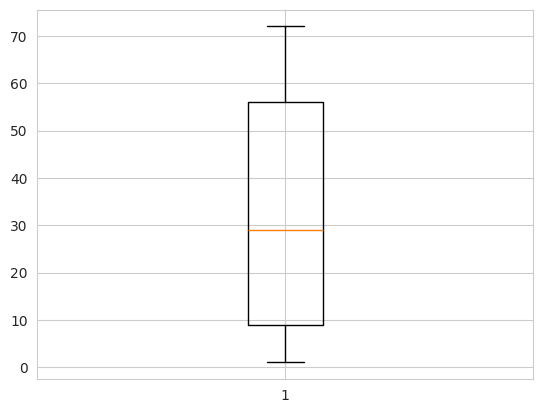

MonthlyCharges


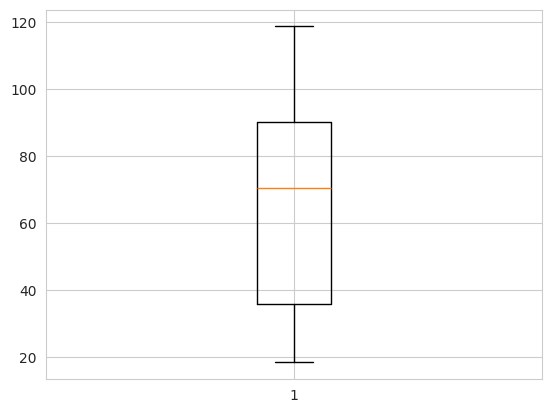

TotalCharges


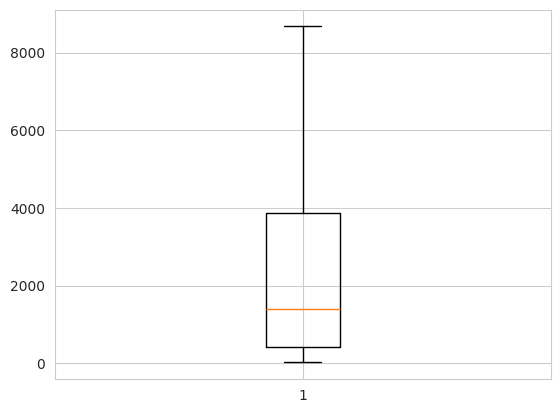

In [174]:
# Check for outliers in the numerical variables
# Use boxplot

for col in ['tenure','MonthlyCharges','TotalCharges']:
    print(col)
    plt.boxplot(Data_All[col])
    plt.show()

- **No outliers** in out Test Dataset numeric columns

### Normality Testing

We will perfom normality test on the three numeric variables to look for signs of skewedness using the D’Agostino’s K^2 Test.

In [175]:
# D’Agostino’s K^2 Test on monthly charges

stat, p = stats.normaltest(Data_All['MonthlyCharges'])

print('Statistics=%.5f, p=%.3f' % (stat, p))

# significance level (5%) for the test
alpha = 0.05

if p > alpha:
    print('the sample is normally distributed')
else:
    print('the sample is skewed')

Statistics=7510.47646, p=0.000
the sample is skewed


In [176]:
# D’Agostino’s K^2 Test on tenure

stat, p = stats.normaltest(Data_All['tenure'])

print('Statistics=%.5f, p=%.3f' % (stat, p))

# significance level (5%) for the test
alpha = 0.05

if p > alpha:
	print('the sample is normally distributed')
else:
	print('the sample is skewed')

Statistics=53555.33858, p=0.000
the sample is skewed


In [177]:
## D’Agostino’s K^2 Test on TotalCharges
stat, p = stats.normaltest(Data_All['TotalCharges'])

print('Statistics=%.5f, p=%.3f' % (stat, p))

# significance level (5%) for the test
alpha = 0.05

if p > alpha:
	print('the sample is normally distributed')
else:
	print('the sample is skewed')

Statistics=569.05463, p=0.000
the sample is skewed


In [178]:
# reset index and save to csv

Data_All.reset_index(drop=True, inplace=True)
Data_All.to_csv('Dataset/Train_Data.csv', index=False)

In [179]:
# view Data Types

print("**Data Types**")
Data_All.dtypes.value_counts()

**Data Types**


object     17
float64     2
int64       1
Name: count, dtype: int64

## Clean test data

In [180]:
data_test = pd.read_csv('Dataset/Telco-churn-second-2000.csv')

In [181]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2000 non-null   object 
 1   gender            2000 non-null   object 
 2   SeniorCitizen     2000 non-null   int64  
 3   Partner           2000 non-null   object 
 4   Dependents        2000 non-null   object 
 5   tenure            2000 non-null   int64  
 6   PhoneService      2000 non-null   object 
 7   MultipleLines     2000 non-null   object 
 8   InternetService   2000 non-null   object 
 9   OnlineSecurity    2000 non-null   object 
 10  OnlineBackup      2000 non-null   object 
 11  DeviceProtection  2000 non-null   object 
 12  TechSupport       2000 non-null   object 
 13  StreamingTV       2000 non-null   object 
 14  StreamingMovies   2000 non-null   object 
 15  Contract          2000 non-null   object 
 16  PaperlessBilling  2000 non-null   object 


In [182]:
# change Dtype of TotalCharges column from object to numeric

data_test['TotalCharges'] = pd.to_numeric(data_test['TotalCharges'], errors='coerce')

In [183]:
# view Missing Values in TotalCharges column

data_test[np.isnan(data_test['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN
826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
1380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN


In [184]:
# Drop rows where tenure = 0

data_test.drop(labels=data_test[data_test['tenure'] == 0].index, axis=0, inplace=True)

In [185]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1997 non-null   object 
 1   gender            1997 non-null   object 
 2   SeniorCitizen     1997 non-null   int64  
 3   Partner           1997 non-null   object 
 4   Dependents        1997 non-null   object 
 5   tenure            1997 non-null   int64  
 6   PhoneService      1997 non-null   object 
 7   MultipleLines     1997 non-null   object 
 8   InternetService   1997 non-null   object 
 9   OnlineSecurity    1997 non-null   object 
 10  OnlineBackup      1997 non-null   object 
 11  DeviceProtection  1997 non-null   object 
 12  TechSupport       1997 non-null   object 
 13  StreamingTV       1997 non-null   object 
 14  StreamingMovies   1997 non-null   object 
 15  Contract          1997 non-null   object 
 16  PaperlessBilling  1997 non-null   object 
 17  

In [186]:
# Reset index

data_test.reset_index(drop=True, inplace=True)

In [187]:
# check for null values

data_test.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [188]:
# check dtype of SeniorCitizen column

data_test['SeniorCitizen'].dtypes

dtype('int64')

In [189]:
# Replace 0 values with 'No' and 1 values with 'Yes'

data_test['SeniorCitizen'] = data_test['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})

In [190]:
# change dtype to object

data_test['SeniorCitizen'] = data_test['SeniorCitizen'].astype('object')

In [191]:
# view unique values of each column

for column in data_test.columns:
    print('Column: {} - Unique Values: {}'.format(column, data_test[column].unique()))

Column: customerID - Unique Values: ['7613-LLQFO' '4568-TTZRT' '9513-DXHDA' ... '4816-JBHOV' '8920-NAVAY'
 '1699-TLDLZ']
Column: gender - Unique Values: ['Male' 'Female']
Column: SeniorCitizen - Unique Values: ['No' 'Yes']
Column: Partner - Unique Values: ['No' 'Yes']
Column: Dependents - Unique Values: ['No' 'Yes']
Column: tenure - Unique Values: [12  9 27  1 24 14 32 11 38 54 29 44 59  3 18 67 22 33  5  2 72 16  8 23
 50 17 68 25 71 46 48 61 37 65 49 64 21 10  6 51 47 52 35 45  4 60 28 39
 30 55 58 26 43 56 36 13 70 69 41 15 19 31 34 66 40  7 53 63 42 57 62 20]
Column: PhoneService - Unique Values: ['Yes' 'No']
Column: MultipleLines - Unique Values: ['Yes' 'No' 'No phone service']
Column: InternetService - Unique Values: ['Fiber optic' 'No' 'DSL']
Column: OnlineSecurity - Unique Values: ['No' 'No internet service' 'Yes']
Column: OnlineBackup - Unique Values: ['No' 'No internet service' 'Yes']
Column: DeviceProtection - Unique Values: ['No' 'No internet service' 'Yes']
Column: TechSup

In [192]:
# save test data to csv

data_test.to_csv('Dataset/Test_Data.csv', index=False)